# Olist Database - Temporal Evaluation

**Author:** Alejandro Mezio

Does the delivery-time model survive a train-on-the-past / test-on-the-future evaluation?

## 9.&nbsp;Motivation

Part 2 evaluates all models with a **random** train/test split. But the orders span February 2017 to August 2018, so a random split interleaves training and test orders in time: the model gets to "see the future" of the period it is tested on. A deployed estimator only ever predicts forward.

This notebook quantifies how much that matters. We evaluate three models under two protocols:

| | Random split (Part 2 protocol) | Temporal split (deployment-faithful) |
|---|---|---|
| Train | 80% of orders, random | Orders **purchased and delivered** before the cutoff date |
| Test | 20% of orders, random | Orders purchased after the cutoff |

The models: a **constant median** predictor (floor), **linear regression** (scientific baseline), and **XGBoost** with the best hyperparameters found by the randomized search in Part 2 (no re-tuning here; re-tuning on the temporal train would be a separate, fair improvement).

Note the strict definition of the temporal train set: an order purchased before the cutoff but delivered after it would not have its label available at the cutoff date, so it is excluded from training. This mimics what a model trained on that date could actually know.

We also keep **Olist's original estimator** as the business benchmark row, and we estimate the uncertainty of the temporal result with an **expanding-window cross-validation** (`TimeSeriesSplit`).

### Libraries and data

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor

%matplotlib inline

In [2]:
models_path = './models'
os.makedirs(models_path, exist_ok=True)

In [3]:
# Function to load the dataframes together with their datatype dictionaries
def load_dataframe(base_path, name):
    dtype_path = Path(base_path) / f"{name}_datatypes.txt"
    csv_path = Path(base_path) / f"{name}.csv"

    with open(dtype_path, "r") as file:
        datatypes = json.load(file)

    # Extract the date columns
    datetime_cols = [col for col, dtype in datatypes.items() if dtype == 'datetime64[ns]']
    for col in datetime_cols:
        del datatypes[col]

    return pd.read_csv(csv_path, dtype=datatypes, parse_dates=datetime_cols)

df_final = load_dataframe("./bbdd_limpia", "dataset_final_agrupado")
len(df_final)

90137

### Features, targets and pipeline (identical to Part 2)

In [4]:
numerical_features = ['price', 'freight_value', 'product_chosen_weight', 'distance_km', 'sales_same_state']
categorical_features = ['product_venta', 'rutas']
target_columns = ['days_to_delivered', 'days_estimated']

X = df_final[numerical_features + categorical_features]
y = df_final[target_columns]

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), numerical_features),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ])

In [5]:
# Best XGBoost hyperparameters found by the randomized search in Part 2
# (printed under section "6. XGBoost": Best MAE (CV) = 4.4276)
XGB_BEST = dict(
    colsample_bytree=0.9473671498667567,
    gamma=0.7176274029426006,
    learning_rate=0.040574811555119,
    max_depth=7,
    min_child_weight=15,
    n_estimators=1148,
    reg_alpha=1.2281606958567808,
    reg_lambda=2.047745290252175,
    subsample=0.9080820523663289,
)

def make_model(name):
    if name == 'median':
        est = DummyRegressor(strategy='median')
    elif name == 'linreg':
        est = LinearRegression()
    elif name == 'xgb':
        est = XGBRegressor(objective='reg:absoluteerror', tree_method='hist',
                           random_state=888, n_jobs=-1, **XGB_BEST)
    return Pipeline(steps=[('preprocessor', make_preprocessor()), ('model', est)])

## 10.&nbsp;The two protocols

### Protocol A: random split (exactly as in Part 2)

In [6]:
X_train_rnd, X_test_rnd, y_train_rnd, y_test_rnd = train_test_split(X, y, test_size=0.2, random_state=888)
len(X_train_rnd), len(X_test_rnd)

(72109, 18028)

### Protocol B: temporal split

Cutoff = the 80% quantile of `order_purchase_timestamp`, so the test fraction matches Protocol A's 20%.

- **Test**: orders purchased on or after the cutoff.
- **Train**: orders purchased before the cutoff **and also delivered before it** (their label exists at the cutoff date).

In [7]:
ts = df_final['order_purchase_timestamp']
cutoff = ts.quantile(0.8)

test_mask = ts >= cutoff
train_mask = (ts < cutoff) & (df_final['order_delivered_customer_date'] < cutoff)
dropped_undelivered = int(((ts < cutoff) & ~train_mask).sum())

X_train_tmp, y_train_tmp = X[train_mask], y[train_mask]
X_test_tmp, y_test_tmp = X[test_mask], y[test_mask]

print(f"Cutoff date: {cutoff}")
print(f"Temporal train: {len(X_train_tmp)} orders | temporal test: {len(X_test_tmp)} orders")
print(f"Orders purchased before cutoff but not yet delivered (excluded from train): {dropped_undelivered}")

Cutoff date: 2018-05-26 09:53:39
Temporal train: 70294 orders | temporal test: 18028 orders
Orders purchased before cutoff but not yet delivered (excluded from train): 1815


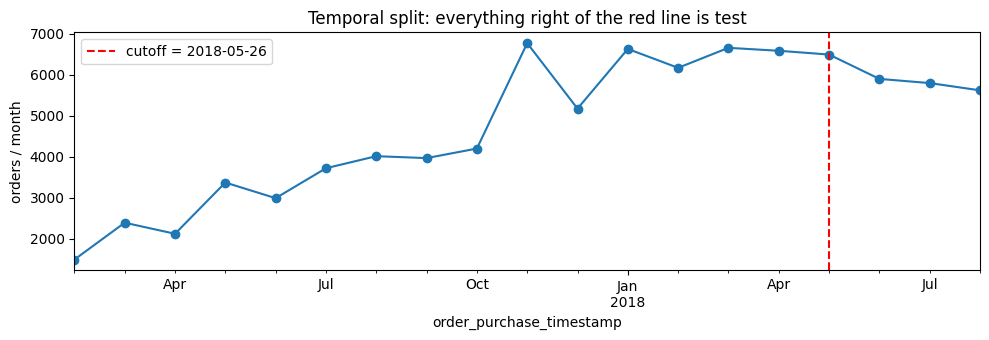

In [8]:
# Monthly order volume with the cutoff marked
monthly = df_final.set_index('order_purchase_timestamp').resample('MS').size()
fig, ax = plt.subplots(figsize=(10, 3.5))
monthly.plot(ax=ax, marker='o')
ax.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff.date()}')
ax.set_ylabel('orders / month')
ax.set_title('Temporal split: everything right of the red line is test')
ax.legend()
plt.tight_layout()
plt.show()

A quick distribution check: the temporal test months could differ structurally from the training period (seasonality, growth, mix of routes). We compare the target distribution between the two protocols' test sets.

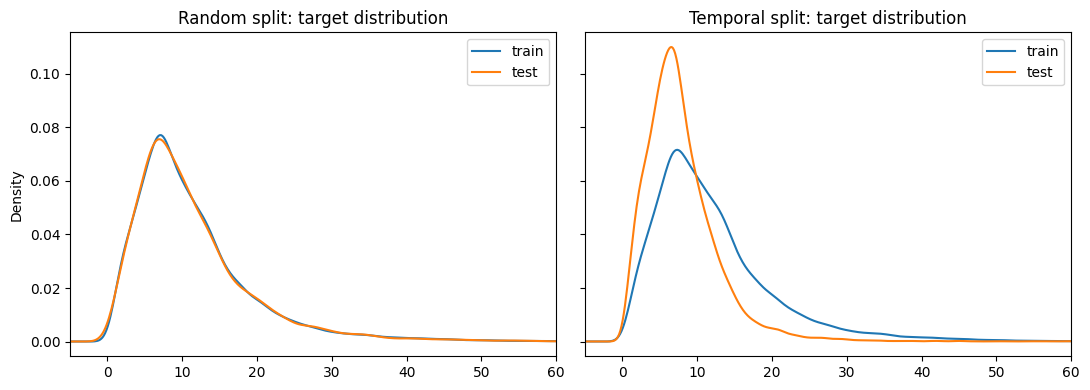

,random train,random test,temporal train,temporal test
count,72109.00,18028.0,70294.00,18028.00
mean,11.44,11.4,12.11,7.94
std,8.29,8.3,8.52,5.32
min,0.00,0.0,0.00,0.00
25%,6.00,6.0,7.00,5.00
50%,9.00,9.0,10.00,7.00
75%,14.00,14.0,15.00,10.00
max,87.00,85.0,87.00,78.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, y_tr, y_te) in zip(axes, [('Random', y_train_rnd, y_test_rnd),
                                         ('Temporal', y_train_tmp, y_test_tmp)]):
    y_tr['days_to_delivered'].plot(kind='kde', ax=ax, label='train')
    y_te['days_to_delivered'].plot(kind='kde', ax=ax, label='test')
    ax.set_title(f'{name} split: target distribution')
    ax.set_xlim(-5, 60)
    ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    'random train': y_train_rnd['days_to_delivered'].describe(),
    'random test': y_test_rnd['days_to_delivered'].describe(),
    'temporal train': y_train_tmp['days_to_delivered'].describe(),
    'temporal test': y_test_tmp['days_to_delivered'].describe(),
}).round(2)

## 11.&nbsp;Fit and evaluate under both protocols

Each (model, protocol) pair is fitted or loaded from `models/` (delete the pickle to force a re-fit). XGBoost is the only slow one (~minutes per fit).

In [10]:
def metrics(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': root_mean_squared_error(y_true, y_pred)}

def fit_or_load(name, protocol, X_tr, y_tr):
    path = os.path.join(models_path, f'part3_{name}_{protocol}.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            pipe = pickle.load(f)
    else:
        pipe = make_model(name)
        pipe.fit(X_tr, y_tr['days_to_delivered'])
        with open(path, 'wb') as f:
            pickle.dump(pipe, f)
    return pipe

protocols = {
    'random': (X_train_rnd, y_train_rnd, X_test_rnd, y_test_rnd),
    'temporal': (X_train_tmp, y_train_tmp, X_test_tmp, y_test_tmp),
}

rows = []
for protocol, (X_tr, y_tr, X_te, y_te) in protocols.items():
    # Business benchmark: Olist's original estimate (no fitting involved)
    m = metrics(y_te['days_to_delivered'], y_te['days_estimated'])
    rows.append({'model': 'olist_estimator', 'protocol': protocol, **m})
    for name in ['median', 'linreg', 'xgb']:
        pipe = fit_or_load(name, protocol, X_tr, y_tr)
        m = metrics(y_te['days_to_delivered'], pipe.predict(X_te))
        rows.append({'model': name, 'protocol': protocol, **m})
        print(f"done: {name} / {protocol} -> MAE {m['MAE']:.3f}")

results = pd.DataFrame(rows)
results

done: median / random -> MAE 5.603
done: linreg / random -> MAE 4.823
done: xgb / random -> MAE 4.383
done: median / temporal -> MAE 4.336
done: linreg / temporal -> MAE 4.883
done: xgb / temporal -> MAE 3.824


,model,protocol,MAE,RMSE
0,olist_estimator,random,12.628189,14.534564
1,median,random,5.603450,8.634618
2,linreg,random,4.822574,7.160770
3,xgb,random,4.383433,7.132490
4,olist_estimator,temporal,13.494287,16.214205
5,median,temporal,4.336088,5.702098
6,linreg,temporal,4.883106,6.105611
7,xgb,temporal,3.823611,5.190423


In [11]:
# Side-by-side comparison: the temporal-vs-random gap is the headline number of this notebook
table = results.pivot(index='model', columns='protocol', values=['MAE', 'RMSE'])
table = table.reindex(['olist_estimator', 'median', 'linreg', 'xgb'])
table[('MAE', 'gap')] = table[('MAE', 'temporal')] - table[('MAE', 'random')]
table[('MAE', 'gap %')] = 100 * table[('MAE', 'gap')] / table[('MAE', 'random')]
table.round(3)

MAE             RMSE             MAE        
protocol         random temporal  random temporal    gap   gap %
model                                                           
olist_estimator  12.628   13.494  14.535   16.214  0.866   6.858
median            5.603    4.336   8.635    5.702 -1.267 -22.618
linreg            4.823    4.883   7.161    6.106  0.061   1.255
xgb               4.383    3.824   7.132    5.190 -0.560 -12.771

## 12.&nbsp;Uncertainty of the temporal estimate: expanding-window CV

A single temporal split is one draw: the test window might be an easy or a hard stretch of months. `TimeSeriesSplit` gives us several train-on-past / validate-on-later-window folds over the time-sorted data (we apply the same delivered-before-cutoff rule to each fold's training part). We run it for linear regression and XGBoost.

In [12]:
df_sorted = df_final.sort_values('order_purchase_timestamp').reset_index(drop=True)
X_sorted = df_sorted[numerical_features + categorical_features]
y_sorted = df_sorted['days_to_delivered']

tscv_rows = []
for name in ['linreg', 'xgb']:
    fold_maes = []
    for k, (tr_idx, va_idx) in enumerate(TimeSeriesSplit(n_splits=5).split(X_sorted)):
        fold_cutoff = df_sorted['order_purchase_timestamp'].iloc[va_idx[0]]
        delivered = df_sorted['order_delivered_customer_date'].iloc[tr_idx] < fold_cutoff
        tr_ok = tr_idx[delivered.to_numpy()]
        pipe = make_model(name)
        pipe.fit(X_sorted.iloc[tr_ok], y_sorted.iloc[tr_ok])
        mae = mean_absolute_error(y_sorted.iloc[va_idx], pipe.predict(X_sorted.iloc[va_idx]))
        fold_maes.append(mae)
        print(f"{name} fold {k}: cutoff {fold_cutoff.date()}, train {len(tr_ok)}, val {len(va_idx)}, MAE {mae:.3f}")
    tscv_rows.append({'model': name, 'MAE mean': np.mean(fold_maes),
                      'MAE std': np.std(fold_maes), 'folds': np.round(fold_maes, 3)})

tscv = pd.DataFrame(tscv_rows)
tscv

linreg fold 0: cutoff 2017-07-23, train 13598, val 15022, MAE 3.782
linreg fold 1: cutoff 2017-11-13, train 28278, val 15022, MAE 5.544
linreg fold 2: cutoff 2018-01-23, train 42109, val 15022, MAE 6.457
linreg fold 3: cutoff 2018-04-02, train 56351, val 15022, MAE 4.590
linreg fold 4: cutoff 2018-06-12, train 73010, val 15022, MAE 5.044
xgb fold 0: cutoff 2017-07-23, train 13598, val 15022, MAE 3.713
xgb fold 1: cutoff 2017-11-13, train 28278, val 15022, MAE 5.719
xgb fold 2: cutoff 2018-01-23, train 42109, val 15022, MAE 6.669
xgb fold 3: cutoff 2018-04-02, train 56351, val 15022, MAE 4.140
xgb fold 4: cutoff 2018-06-12, train 73010, val 15022, MAE 3.993


,model,MAE mean,MAE std,folds
0,linreg,5.083372,0.898423,"[3.782, 5.544, 6.457, 4.59, 5.044]"
1,xgb,4.847022,1.148510,"[3.713, 5.719, 6.669, 4.14, 3.993]"


In [13]:
# Persist every number for the README and downstream write-up
out = {
    'cutoff': str(cutoff),
    'n_train_temporal': int(len(X_train_tmp)),
    'n_test_temporal': int(len(X_test_tmp)),
    'dropped_undelivered': dropped_undelivered,
    'results': results.to_dict(orient='records'),
    'tscv': [{k: (v.tolist() if hasattr(v, 'tolist') else v) for k, v in r.items()}
             for r in tscv_rows],
}
with open('scripts/temporal_eval_results.json', 'w') as f:
    json.dump(out, f, indent=2, default=str)
print('saved scripts/temporal_eval_results.json')

saved scripts/temporal_eval_results.json


## 13.&nbsp;Takeaways

**1. The headline survives forward evaluation.** Trained only on orders delivered before 2018-05-26 and tested on the ~3 months after, XGBoost reaches MAE 3.82 days, better than the random-split 4.38. No degradation appears, because the final window is intrinsically easier: mid-2018 deliveries are faster and much less dispersed (the constant median alone scores 4.34 there vs 5.60 on the random test, and test RMSEs drop across the board).

**2. But random-split CV badly understates deployment uncertainty.** Expanding-window CV gives XGBoost MAE 4.85 ± 1.15 across five forward windows (folds range 3.71 to 6.67 days), versus the random CV's 4.43 with fold std ≈ 0.03. The point estimate moves mildly; the error bar widens ~30×. Which period you deploy into matters far more than which random fold you validate on: the operative uncertainty for a promised-date system is the ±1.1 days.

**3. The ranking mostly survives, with one instructive exception.** XGBoost beats linear regression under every protocol (temporal test 3.82 vs 4.88; expanding-window 4.85 vs 5.08). But on the easy final window the constant median (4.34) also beats linear regression (4.88): a model calibrated to a harder past over-predicts an easier future, while a constant from the past happens to land well. Single-window comparisons inherit the window's character.

**4. The business benchmark degrades exactly where the models improve.** Olist's estimator worsens from 12.63 to 13.49 MAE on the final window: its padded promises (inflated further around the May-June 2018 truckers' strike, which sits right at the cutoff) stretch while actual deliveries speed up.

**Bottom line:** the random split did not inflate the headline here (if anything the final window flatters it), but it hid the real uncertainty structure. The honest deployment claim from this data: **forward MAE ≈ 4.8 ± 1.1 days across periods, 3.82 on the most recent window.**